In [29]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Detect experiment data directory
EXP_DIR = "../../experiment_data"
if not os.path.exists(EXP_DIR):
    EXP_DIR = "experiment_data"
if not os.path.exists(EXP_DIR):
    EXP_DIR = "../experiment_data"

experiments = [
    ("no_wal_read_dominant", "No WAL (Read 90% / Write 10%)", False, "Read Dominant (90% Read)"),
    ("no_wal_write_dominant", "No WAL (Write 90% / Read 10%)", False, "Write Dominant (90% Write)"),
    ("wal_read_dominant", "With WAL (Read 90% / Write 10%)", True, "Read Dominant (90% Read)"),
    ("wal_write_dominant", "With WAL (Write 90% / Read 10%)", True, "Write Dominant (90% Write)"),
]

all_dfs = []

for folder, label, wal_enabled, workload in experiments:
    exp_path = os.path.join(EXP_DIR, folder)
    if not os.path.exists(exp_path):
        continue

    method_dfs = []
    for file, method in [("mem_get_summary.csv", "GET"), ("mem_put_summary.csv", "PUT"), ("mem_delete_summary.csv", "DELETE")]:
        file_path = os.path.join(exp_path, file)
        if os.path.exists(file_path) and os.path.getsize(file_path) > 0:
            try:
                df = pd.read_csv(file_path)
                if not df.empty and "timestamp_nanos" in df.columns:
                    df["method"] = method
                    method_dfs.append(df)
            except Exception as e:
                print(f"Error reading {file_path}: {e}")

    if not method_dfs:
        continue

    exp_df = pd.concat(method_dfs, ignore_index=True)
    exp_df["experiment"] = label
    exp_df["wal"] = "With WAL" if wal_enabled else "No WAL"
    exp_df["workload"] = workload

    # Calculate elapsed duration (dt) between tiers from timestamp_nanos
    exp_df = exp_df.sort_values(by=["method", "current_qps"]).reset_index(drop=True)
    exp_df["dt_sec"] = exp_df.groupby("method")["timestamp_nanos"].diff() / 1e9
    exp_df["dt_sec"] = exp_df["dt_sec"].fillna(10.0)
    exp_df.loc[exp_df["dt_sec"] <= 0, "dt_sec"] = 10.0

    # Tier-level duration and total throughput
    tier_dt = exp_df.groupby("current_qps")["dt_sec"].mean().reset_index().rename(columns={"dt_sec": "tier_dt_sec"})
    tier_totals = exp_df.groupby("current_qps")["total_ops"].sum().reset_index().rename(columns={"total_ops": "tier_total_ops"})

    # Convert nanoseconds to microseconds
    p99_e2e_col = "p99_e2e_ns" if "p99_e2e_ns" in exp_df.columns else "p99_ns"
    p50_e2e_col = "p50_e2e_ns" if "p50_e2e_ns" in exp_df.columns else "p50_ns"
    exp_df["p99_e2e_us"] = exp_df[p99_e2e_col] / 1000.0
    exp_df["p50_e2e_us"] = exp_df[p50_e2e_col] / 1000.0

    exp_df = exp_df.merge(tier_totals, on="current_qps").merge(tier_dt, on="current_qps")
    exp_df["real_qps"] = exp_df["tier_total_ops"] / exp_df["tier_dt_sec"]
    all_dfs.append(exp_df)

records = pd.concat(all_dfs, ignore_index=True)


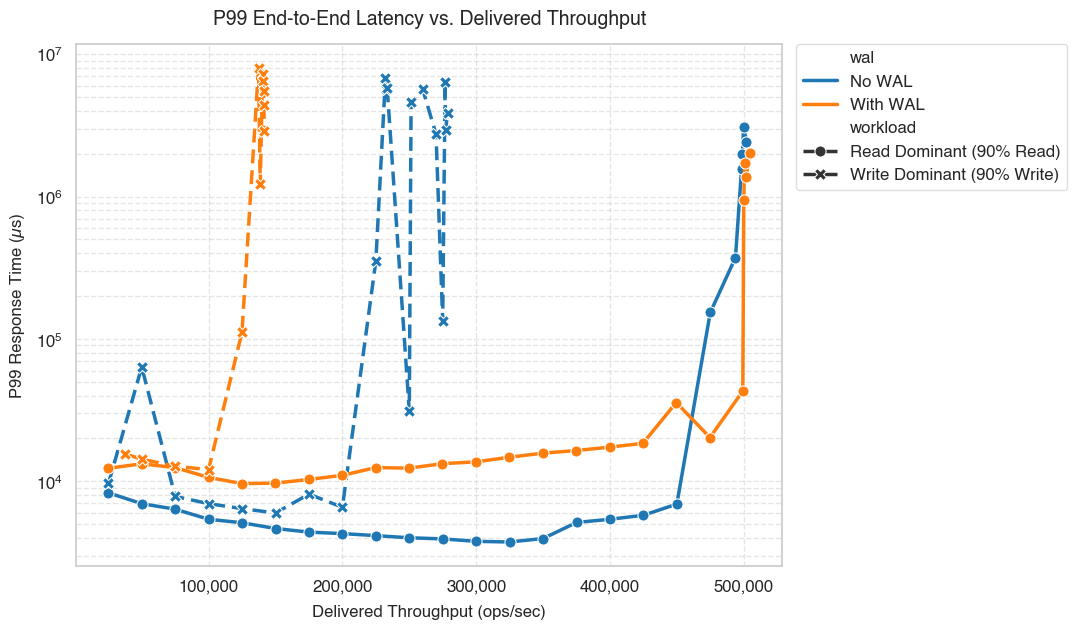

In [30]:
# Seaborn styling configuration
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["font.sans-serif"] = "Helvetica, Arial, DejaVu Sans"

fig, ax = plt.subplots(figsize=(11, 6.5))

# Distinct color coding: WAL is one color, No WAL is the other
palette = {"No WAL": "#1f77b4", "With WAL": "#ff7f0e"}

# Styling: distinct markers and dashes for workload types
dashes = {"Read Dominant (90% Read)": (1, 0), "Write Dominant (90% Write)": (4, 2)}
markers = {"Read Dominant (90% Read)": "o", "Write Dominant (90% Write)": "X"}

sns.lineplot(
    data=records,
    x="real_qps",
    y="p99_e2e_us",
    hue="wal",
    style="workload",
    palette=palette,
    dashes=dashes,
    markers=markers,
    linewidth=2.5,
    markersize=8,
    errorbar=None,
    ax=ax,
)

# Logarithmic scale for P99 tail latency
ax.set_yscale("log")

# Titles and axis labels
ax.set_title("P99 End-to-End Latency vs. Delivered Throughput", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Delivered Throughput (ops/sec)", fontsize=12, labelpad=8)
ax.set_ylabel("P99 Response Time (µs)", fontsize=12, labelpad=8)

# Format thousands separators for QPS
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{int(x):,}"))
ax.grid(True, which="both", linestyle="--", alpha=0.5)

# Place clean legend outside to avoid obscuring curves
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, frameon=True, framealpha=0.95, edgecolor="#ddd")

plt.tight_layout()
plt.show()